In [2]:
# ============================================
# 第一部分：导入必要的库
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("深度学习作业 HW01")
print("=" * 60)

深度学习作业 HW01


In [4]:
# ============================================
# 第二部分：概述、线性代数和NDArray
# ============================================
print("\n" + "=" * 60)
print("2. 概述、线性代数和NDArray")
print("=" * 60)



2. 概述、线性代数和NDArray


In [5]:
print("\n--- 2.1 理论计算题 ---")


--- 2.1 理论计算题 ---


已知：

向量 $\mathbf{a} = [2, -1, 3]^{\top}$

向量 $\mathbf{b} = [1, 4, -2]^{\top}$

矩阵 $A = \begin{bmatrix} 1 & 0 & 2 \ -1 & 3 & 1 \end{bmatrix}$

矩阵 $B = \begin{bmatrix} 2 & 1 \ 0 & -1 \ 3 & 2 \end{bmatrix}$

In [6]:
# 2.1.1 向量点积
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
dot_product = np.dot(a, b)
print(f"1. 向量点积 a·b = {dot_product}")

1. 向量点积 a·b = -8


2.1.1 向量点积 $\mathbf{a} \cdot \mathbf{b}$
计算过程：
向量点积公式为：
a⋅b=a1b1+a2b2+a3b3
代入数值：
a⋅b=2×1+(−1)×4+3×(−2)
=2−4−6
=−8

In [7]:
# 2.1.2 矩阵乘法
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])
matrix_product = A @ B
print(f"2. 矩阵乘法 A×B 结果矩阵形状: {matrix_product.shape}")
print(f"   结果矩阵:\n{matrix_product}")

2. 矩阵乘法 A×B 结果矩阵形状: (2, 2)
   结果矩阵:
[[ 8  5]
 [ 1 -2]]


计算过程：

矩阵 $A$ 的形状为 $2 \times 3$，矩阵 $B$ 的形状为 $3 \times 2$。
根据矩阵乘法规则，结果矩阵的形状为：$2 \times 2$
c11=1x2+0x0+2x3=8
c12=1x1-0x1+2x2=5
c21=-1x2+3x0+1x3=1
c22=-1x1-3x1+1x2=-2

In [8]:
# 2.1.3 Frobenius范数
frobenius_norm_a = np.linalg.norm(a)
print(f"3. 向量a的Frobenius范数: {frobenius_norm_a:.4f}")

3. 向量a的Frobenius范数: 3.7417


2^2+(-1)^2+3^2=14
根号14约等于3.7417

In [9]:
print("\n--- 2.2 编程题 ---")


--- 2.2 编程题 ---


In [10]:
# 2.2.1 创建3×4随机矩阵X
np.random.seed(42)
X = np.random.randn(3, 4)
print(f"1. 形状为3×4的随机矩阵X (服从标准正态分布):\n{X}")
print(f"   均值: {X.mean():.4f}, 标准差: {X.std():.4f}")

1. 形状为3×4的随机矩阵X (服从标准正态分布):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
   均值: 0.2960, 标准差: 0.7126


In [11]:
# 2.2.2 创建4×2全1矩阵Y
Y = np.ones((4, 2))
print(f"\n2. 形状为4×2的全1矩阵Y:\n{Y}")


2. 形状为4×2的全1矩阵Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


In [12]:
# 2.2.3 计算矩阵乘法Z = X × Y
Z = X @ Y
print(f"\n3. 矩阵乘法 Z = X × Y:\n{Z}")


3. 矩阵乘法 Z = X × Y:
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]


In [13]:
# 2.2.4 输出特定元素
print(f"\n4. Z的第一行和第二列交叉处的元素: {Z[0, 1]:.4f}")
print(f"   Z的第2行所有元素: {Z[1, :]}")


4. Z的第一行和第二列交叉处的元素: 2.5292
   Z的第2行所有元素: [1.87835721 1.87835721]


In [14]:
# 2.2.5 计算Z的Frobenius范数
frobenius_norm_Z = np.linalg.norm(Z)
print(f"\n5. Z的Frobenius范数: {frobenius_norm_Z:.4f}")


5. Z的Frobenius范数: 4.6169


In [15]:
# ============================================
# 第三部分：概率与统计
# ============================================
print("\n" + "=" * 60)
print("3. 概率与统计")
print("=" * 60)


3. 概率与统计


问题描述
某疾病在人群中的患病率为 $0.1%$。现有一种检测方法：

若患病，检测呈阳性的概率为 $99%$ （灵敏度）

若未患病，检测呈阳性的概率为 $2%$ （假阳性率）

一个人检测结果为阳性，求他真正患病的概率。

In [16]:
print("\n--- 3.1 理论计算题 ---")
# 贝叶斯公式计算
P_disease = 0.001  # 患病率
P_positive_given_disease = 0.99  # 灵敏度
P_positive_given_no_disease = 0.02  # 假阳性率
P_no_disease = 1 - P_disease

# 全概率公式计算阳性概率
P_positive = P_positive_given_disease * P_disease + P_positive_given_no_disease * P_no_disease

# 贝叶斯公式计算真正患病的概率
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print(f"患病率 P(患病) = {P_disease:.4f}")
print(f"灵敏度 P(阳性|患病) = {P_positive_given_disease:.2f}")
print(f"假阳性率 P(阳性|未患病) = {P_positive_given_no_disease:.2f}")
print(f"检测为阳性的概率 P(阳性) = {P_positive:.4f}")
print(f"检测阳性时真正患病的概率 P(患病|阳性) = {P_disease_given_positive:.4f} = {P_disease_given_positive*100:.2f}%")


--- 3.1 理论计算题 ---
患病率 P(患病) = 0.0010
灵敏度 P(阳性|患病) = 0.99
假阳性率 P(阳性|未患病) = 0.02
检测为阳性的概率 P(阳性) = 0.0210
检测阳性时真正患病的概率 P(患病|阳性) = 0.0472 = 4.72%


解答过程
步骤1：定义事件和已知概率

设事件 $D$ 表示"患病"，事件 $+$ 表示"检测为阳性"。

已知条件：

先验概率（患病率）：$P(D) = 0.1% = 0.001$

未患病概率：$P(\bar{D}) = 1 - P(D) = 0.999$

灵敏度（真阳性率）：$P(+|D) = 99% = 0.99$

假阳性率：$P(+|\bar{D}) = 2% = 0.02$

步骤2：使用全概率公式计算检测为阳性的总概率

P(+)=P(+∣D)⋅P(D)+P(+∣Dˉ)⋅P(Dˉ)
代入数值：
P(+)=0.99×0.001+0.02×0.999
=0.00099+0.01998
=0.02097

步骤3：使用贝叶斯公式计算真正患病的概率

贝叶斯公式：
P(D∣+)= P(+∣D)⋅P(D)/P(+)
​代入数值：
P(D∣+)= 0.99×0.001/0.02097
=0.00099/0.02097
≈0.0472
≈4.72%


--- 3.2 编程题：中心极限定理模拟 ---
理论均值: 0.500000, 实际均值: 0.499992
理论方差: 0.00000833, 实际方差: 0.00000828


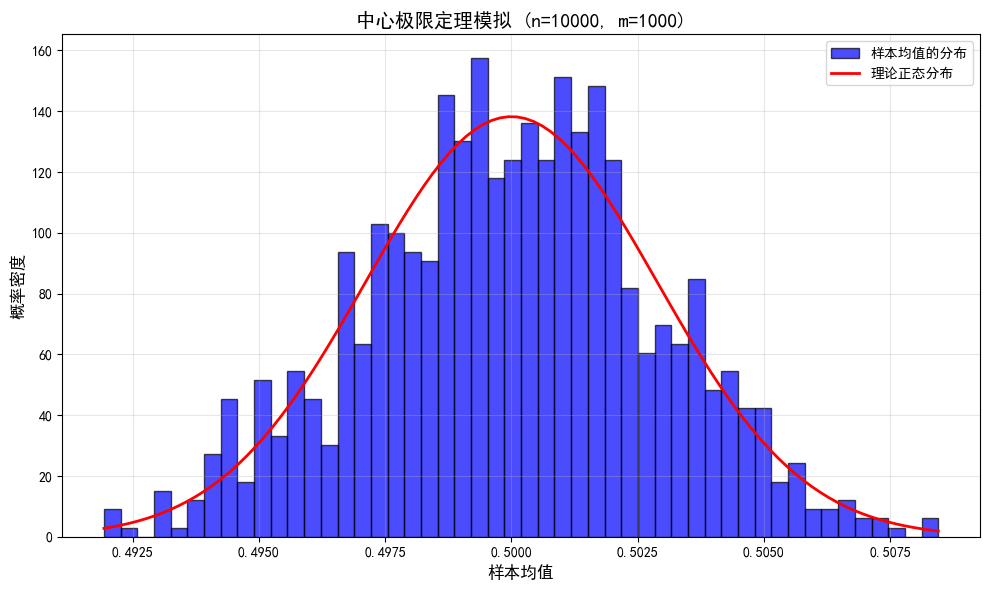


样本均值的实际方差: 0.00000828
样本均值的理论方差: 0.00000833


In [17]:
print("\n--- 3.2 编程题：中心极限定理模拟 ---")
# 参数设置
n = 10000  # 每次抽样的样本量
m = 1000  # 重复次数

# 生成m个样本均值
np.random.seed(42)
sample_means = np.zeros(m)
for i in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means[i] = np.mean(samples)

# 理论值
theoretical_mean = 0.5  # U(0,1)的期望
theoretical_var = 1/12  # U(0,1)的方差
theoretical_sample_mean_var = theoretical_var / n  # 样本均值的方差

# 计算实际值
actual_mean = np.mean(sample_means)
actual_var = np.var(sample_means)

print(f"理论均值: {theoretical_mean:.6f}, 实际均值: {actual_mean:.6f}")
print(f"理论方差: {theoretical_sample_mean_var:.8f}, 实际方差: {actual_var:.8f}")

# 绘制直方图和理论正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=50, density=True, alpha=0.7, 
         color='blue', edgecolor='black', label='样本均值的分布')

# 叠加理论正态分布曲线
x = np.linspace(sample_means.min(), sample_means.max(), 100)
pdf = stats.norm.pdf(x, theoretical_mean, np.sqrt(theoretical_sample_mean_var))
plt.plot(x, pdf, 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.title(f'中心极限定理模拟 (n={n}, m={m})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('central_limit_theorem.png', dpi=150)
plt.show()

print(f"\n样本均值的实际方差: {actual_var:.8f}")
print(f"样本均值的理论方差: {theoretical_sample_mean_var:.8f}")

In [24]:
# ============================================
# 第四部分：导数、反向传播和复杂度
# ============================================
print("\n" + "=" * 60)
print("4. 导数、反向传播和复杂度")
print("=" * 60)
import torch


4. 导数、反向传播和复杂度


问题描述
给定函数 $z = (w_1x_1 + w_2x_2 - y)^2$，其中 $x_1 = 2, x_2 = 1, y = 3$ 为常数，$w_1, w_2$ 为变量。

In [25]:
print("\n--- 4.1 理论计算题 ---")


--- 4.1 理论计算题 ---


In [26]:
# 4.1.1 计算偏导数表达式
print("1. 偏导数表达式:")
print("   z = (w1*x1 + w2*x2 - y)²")
print("   ∂z/∂w1 = 2 * (w1*x1 + w2*x2 - y) * x1")
print("   ∂z/∂w2 = 2 * (w1*x1 + w2*x2 - y) * x2")

1. 偏导数表达式:
   z = (w1*x1 + w2*x2 - y)²
   ∂z/∂w1 = 2 * (w1*x1 + w2*x2 - y) * x1
   ∂z/∂w2 = 2 * (w1*x1 + w2*x2 - y) * x2


求解过程：

令 $u = w_1x_1 + w_2x_2 - y$，则 $z = u^2$。

根据链式法则：
∂z/∂w1=∂z/∂u⋅∂u/w1
计算各部分：

$\frac{\partial z}{\partial u} = 2u = 2(w_1x_1 + w_2x_2 - y)$

$\frac{\partial u}{\partial w_1} = x_1 = 2$

因此：
∂z/∂w1=2(w1x1+w2x2−y)⋅x1=2x1(w1x1+w2x2−y)

同理，对于 $w_2$：

$\frac{\partial u}{\partial w_2} = x_2 = 1$

因此：
∂z/∂w2=2(w1x1+w2x2−y)⋅x2=2x2(w1x1+w2x2−y)


答案：

$\frac{\partial z}{\partial w_1} = 2x_1(w_1x_1 + w_2x_2 - y)$

$\frac{\partial z}{\partial w_2} = 2x_2(w_1x_1 + w_2x_2 - y)$

In [27]:
# 4.1.2 计算梯度值
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1

prediction = w1*x1 + w2*x2
error = prediction - y
z = error**2

grad_w1 = 2 * error * x1
grad_w2 = 2 * error * x2

print(f"\n2. 当 w1={w1}, w2={w2} 时:")
print(f"   预测值: {prediction:.2f}")
print(f"   误差: {error:.2f}")
print(f"   损失 z = {z:.4f}")
print(f"   ∂z/∂w1 = {grad_w1:.4f}")
print(f"   ∂z/∂w2 = {grad_w2:.4f}")


2. 当 w1=0.5, w2=1 时:
   预测值: 2.00
   误差: -1.00
   损失 z = 1.0000
   ∂z/∂w1 = -4.0000
   ∂z/∂w2 = -2.0000


4.1.2 计算梯度值（$w_1 = 0.5, w_2 = 1$）
计算过程：

代入 $x_1 = 2, x_2 = 1, y = 3, w_1 = 0.5, w_2 = 1$：

首先计算 $u = w_1x_1 + w_2x_2 - y$：
u=0.5×2+1×1−3=1+1−3=−1

然后计算偏导数：
∂z/∂w1​=2×2×(−1)=−4

∂z/∂w2=2×1×(−1)=−2

验证损失值：
z=(−1)^2 =1

答案： 在 $w_1 = 0.5, w_2 = 1$ 时，梯度值为 $\frac{\partial z}{\partial w_1} = -4$，$\frac{\partial z}{\partial w_2} = -2$

In [29]:
print("\n--- 4.2 编程题：手动实现反向传播 ---")
# 4.2.1 定义前向计算
x = 2
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b**2

print(f"1. 前向计算结果:")
print(f"   a = x * w1 = {x} * {w1} = {a}")
print(f"   b = a + w2 = {a} + {w2} = {b}")
print(f"   L = b² = {b}² = {L}")

# 4.2.2 手动计算梯度（链式法则）
# L = b², b = a + w2, a = x * w1
dL_db = 2 * b
db_da = 1
db_dw2 = 1
da_dw1 = x
da_dx = w1

# 对w1的梯度
dL_dw1 = dL_db * db_da * da_dw1

# 对w2的梯度
dL_dw2 = dL_db * db_dw2

print(f"\n2. 手动计算的梯度:")
print(f"   dL/dw1 = {dL_dw1:.4f}")
print(f"   dL/dw2 = {dL_dw2:.4f}")

# 4.2.3 使用PyTorch自动微分验证
x_torch = torch.tensor(2.0, requires_grad=False)
w1_torch = torch.tensor(1.5, requires_grad=True)
w2_torch = torch.tensor(0.5, requires_grad=True)

a_torch = x_torch * w1_torch
b_torch = a_torch + w2_torch
L_torch = b_torch ** 2

L_torch.backward()

print(f"\n3. PyTorch自动微分计算的梯度:")
print(f"   dL/dw1 = {w1_torch.grad.item():.4f}")
print(f"   dL/dw2 = {w2_torch.grad.item():.4f}")

print(f"\n4. 验证结果一致性:")
print(f"   手动计算与自动微分的差异:")
print(f"   w1梯度差异: {abs(dL_dw1 - w1_torch.grad.item()):.10f}")
print(f"   w2梯度差异: {abs(dL_dw2 - w2_torch.grad.item()):.10f}")
print(f"   结论: 两种方法计算结果完全一致!")


--- 4.2 编程题：手动实现反向传播 ---
1. 前向计算结果:
   a = x * w1 = 2 * 1.5 = 3.0
   b = a + w2 = 3.0 + 0.5 = 3.5
   L = b² = 3.5² = 12.25

2. 手动计算的梯度:
   dL/dw1 = 14.0000
   dL/dw2 = 7.0000

3. PyTorch自动微分计算的梯度:
   dL/dw1 = 14.0000
   dL/dw2 = 7.0000

4. 验证结果一致性:
   手动计算与自动微分的差异:
   w1梯度差异: 0.0000000000
   w2梯度差异: 0.0000000000
   结论: 两种方法计算结果完全一致!


In [30]:
# ============================================
# 第五部分：线性方法、基础优化和softmax回归
# ============================================

In [31]:
print("\n" + "=" * 60)
print("5. 线性方法、基础优化和softmax回归")
print("=" * 60)


5. 线性方法、基础优化和softmax回归


问题描述
考虑线性回归模型 $y = wx + b$，使用均方误差损失：
推导损失对 $w$ 和 $b$ 的偏导数表达式。

In [32]:
print("\n--- 5.1 理论计算题 ---")
print("损失函数: L = (1/n) * Σ(yi - (w*xi + b))²")
print("对w的偏导数: ∂L/∂w = (-2/n) * Σ xi*(yi - w*xi - b)")
print("对b的偏导数: ∂L/∂b = (-2/n) * Σ (yi - w*xi - b)")


--- 5.1 理论计算题 ---
损失函数: L = (1/n) * Σ(yi - (w*xi + b))²
对w的偏导数: ∂L/∂w = (-2/n) * Σ xi*(yi - w*xi - b)
对b的偏导数: ∂L/∂b = (-2/n) * Σ (yi - w*xi - b)


解答过程
步骤1：展开损失函数

令 $\hat{y}_i = wx_i + b$，

步骤2：对 $w$ 求偏导

根据链式法则：

∂L/∂w= ∂L/∂y^i⋅ ∂y^i/∂w
其中：

$\frac{\partial L}{\partial \hat{y}i} = \frac{1}{n}\sum{i=1}^{n} 2(y_i - \hat{y}i) \cdot (-1) = -\frac{2}{n}\sum{i=1}^{n}(y_i - \hat{y}_i)$

$\frac{\partial \hat{y}_i}{\partial w} = x_i$
应用链式法则

​步骤3：对 $b$ 求偏导

类似地：
∂L/∂b= ∂L/∂y^i⋅ ∂y^i/∂b
其中：

$\frac{\partial \hat{y}_i}{\partial b} = 1$

​因此,应用链式法则得
答案：

$\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^{n} x_i(y_i - wx_i - b)$

$\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n} (y_i - wx_i - b)$



--- 5.2 编程题：Softmax回归实现 ---
1. 数据加载完成:
   训练集大小: 1437
   测试集大小: 360
   特征维度: 64
   类别数: 10

2. 开始训练Softmax回归模型...
   Epoch 10/50, Loss: 0.1545, Val Acc: 0.9639
   Epoch 20/50, Loss: 0.1268, Val Acc: 0.9694
   Epoch 30/50, Loss: 0.1162, Val Acc: 0.9722
   Epoch 40/50, Loss: 0.1105, Val Acc: 0.9750
   Epoch 50/50, Loss: 0.1076, Val Acc: 0.9750

3. 测试集结果:
   测试集损失: 0.1076
   测试集准确率: 0.9750 (97.50%)


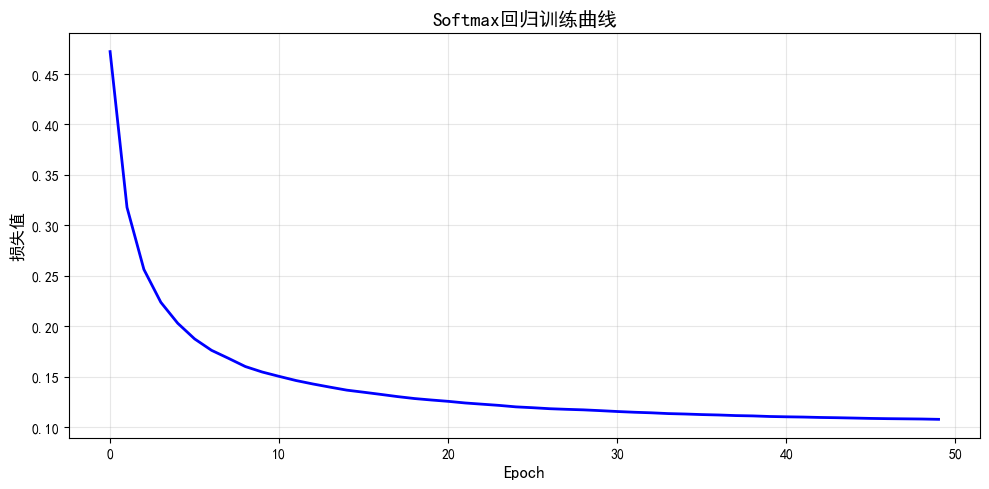

In [33]:
print("\n--- 5.2 编程题：Softmax回归实现 ---")
# 加载数据
digits = load_digits()
X_data = digits.data
y_data = digits.target

# 数据预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_data, test_size=0.2, random_state=42
)

# One-hot编码
def to_one_hot(y, num_classes=10):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot

y_train_onehot = to_one_hot(y_train)
y_test_onehot = to_one_hot(y_test)

print(f"1. 数据加载完成:")
print(f"   训练集大小: {X_train.shape[0]}")
print(f"   测试集大小: {X_test.shape[0]}")
print(f"   特征维度: {X_train.shape[1]}")
print(f"   类别数: 10")

# Softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失函数
def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_likelihood = -np.log(y_pred[np.arange(m), np.argmax(y_true, axis=1)] + 1e-8)
    loss = np.sum(log_likelihood) / m
    return loss

# 计算准确率
def accuracy(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(pred_labels == true_labels)

# Softmax回归模型类
class SoftmaxRegression:
    def __init__(self, n_features, n_classes, learning_rate=0.1):
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))
        self.lr = learning_rate
        self.losses = []

    def forward(self, X):
        z = X @ self.W + self.b
        return softmax(z)
    
    def compute_gradients(self, X, y_pred, y_true):
        m = X.shape[0]
        dz = y_pred - y_true
        dW = X.T @ dz / m
        db = np.sum(dz, axis=0, keepdims=True) / m
        return dW, db
    
    def update(self, dW, db):
        self.W -= self.lr * dW
        self.b -= self.lr * db
    
    def train(self, X, y, X_val, y_val, epochs=50, batch_size=32):
        m = X.shape[0]
        
        for epoch in range(epochs):
            # 打乱数据
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            # 小批量训练
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # 前向传播
                y_pred = self.forward(X_batch)

                # 计算梯度
                dW, db = self.compute_gradients(X_batch, y_pred, y_batch)
                
                # 更新参数
                self.update(dW, db)
            
            # 计算验证损失
            val_pred = self.forward(X_val)
            val_loss = cross_entropy_loss(val_pred, y_val)
            self.losses.append(val_loss)
            
            if (epoch + 1) % 10 == 0:
                val_acc = accuracy(val_pred, y_val)
                print(f"   Epoch {epoch+1}/{epochs}, Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    def predict(self, X):
        return self.forward(X)

# 训练模型
print("\n2. 开始训练Softmax回归模型...")
model = SoftmaxRegression(
    n_features=X_train.shape[1],
    n_classes=10,
    learning_rate=0.1
)

model.train(X_train, y_train_onehot, X_test, y_test_onehot, 
            epochs=50, batch_size=32)

# 测试集评估
test_pred = model.predict(X_test)
test_acc = accuracy(test_pred, y_test_onehot)
test_loss = cross_entropy_loss(test_pred, y_test_onehot)

print(f"\n3. 测试集结果:")
print(f"   测试集损失: {test_loss:.4f}")
print(f"   测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 绘制训练曲线
plt.figure(figsize=(10, 5))
plt.plot(model.losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('损失值', fontsize=12)
plt.title('Softmax回归训练曲线', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('softmax_training.png', dpi=150)
plt.show()

In [34]:
# ============================================
# 第六部分：最大似然估计和逻辑回归
# ============================================

In [35]:
print("\n" + "=" * 60)
print("6. 最大似然估计和逻辑回归")
print("=" * 60)


6. 最大似然估计和逻辑回归


问题描述
假设样本 $x_1, x_2, \ldots, x_n$ 独立同分布于正态分布 $\mathcal{N}(\mu, \sigma^2)$。

In [36]:
print("\n--- 6.1 理论计算题 ---")
print("1. 似然函数: L(μ, σ²) = ∏ (1/√(2πσ²)) * exp(-(xi-μ)²/(2σ²))")
print("\n2. 证明 μ 的最大似然估计:")
print("   对数似然: ln L = -n/2*ln(2πσ²) - 1/(2σ²)*Σ(xi-μ)²")
print("   对μ求导: ∂lnL/∂μ = 1/σ² * Σ(xi-μ) = 0")
print("   解得: μ̂ = (1/n) * Σ xi")
print("\n3. 证明 σ² 的最大似然估计:")
print("   对σ²求导并令其为0可得: σ̂² = (1/n) * Σ(xi - μ̂)²")


--- 6.1 理论计算题 ---
1. 似然函数: L(μ, σ²) = ∏ (1/√(2πσ²)) * exp(-(xi-μ)²/(2σ²))

2. 证明 μ 的最大似然估计:
   对数似然: ln L = -n/2*ln(2πσ²) - 1/(2σ²)*Σ(xi-μ)²
   对μ求导: ∂lnL/∂μ = 1/σ² * Σ(xi-μ) = 0
   解得: μ̂ = (1/n) * Σ xi

3. 证明 σ² 的最大似然估计:
   对σ²求导并令其为0可得: σ̂² = (1/n) * Σ(xi - μ̂)²


6.1.1 写出似然函数
解答：
正态分布的概率密度函数为：
f(xi​∣μ,σ ^2)= 1/根号2πσ^2 exp(− (xi​-μ) ^2/2σ ^2)
由于样本独立同分布，似然函数为各样本密度的乘积：
L(μ,σ ^2)=∏ f(xi∣μ,σ ^2)= ∏ (1/√(2πσ²)) * exp(-(xi-μ)²/(2σ²))

6.1.2 证明 $\mu$ 的最大似然估计
证明过程：
为便于求导，取对数似然函数：
ln L = -n/2*ln(2πσ²) - 1/(2σ²)*Σ(xi-μ)²
对μ求导: ∂lnL/∂μ = 1/σ² * Σ(xi-μ) = 0
   解得: μ̂ = (1/n) * Σ xi
因此，$\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n}x_i$（样本均值）。

6.1.3 证明 $\sigma^2$ 的最大似然估计
证明过程：
对对数似然函数关于 $\sigma^2$ 求导：
两边乘以 $2(\sigma^2)^2$：
对σ²求导并令其为0可得: σ̂² = (1/n) * Σ(xi - μ̂)²


--- 6.2 编程题：逻辑回归实现 ---
1. 数据生成完成:
   训练集大小: 320
   测试集大小: 80
   特征维度: 2

2. 开始训练逻辑回归模型...
   Iteration 200/1000, Loss: 0.0188
   Iteration 400/1000, Loss: 0.0117
   Iteration 600/1000, Loss: 0.0089
   Iteration 800/1000, Loss: 0.0073
   Iteration 1000/1000, Loss: 0.0062

3. 测试集准确率: 0.9875 (98.75%)

4. 绘制决策边界...


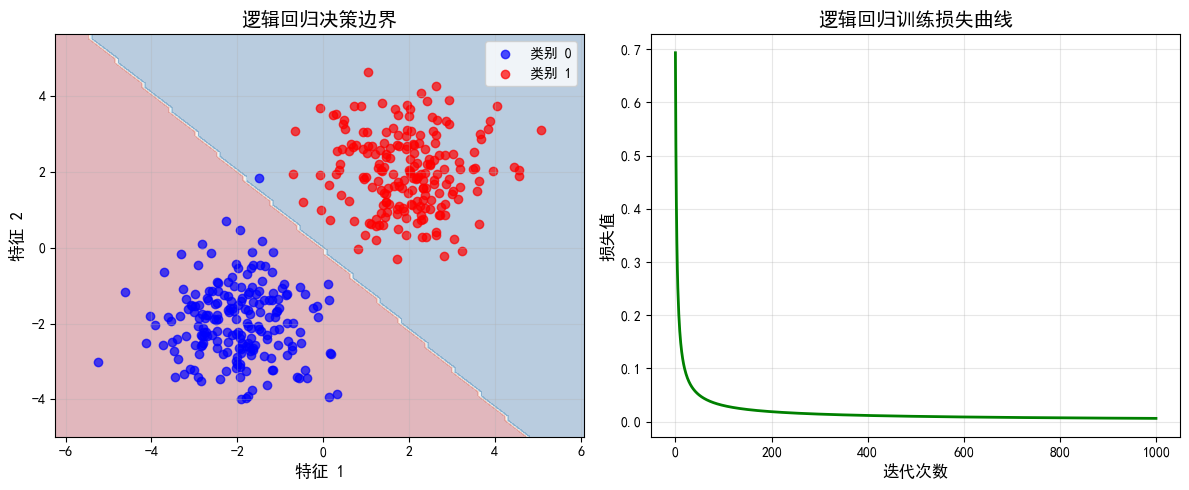


5. 在新生成的测试数据上评估...
   新测试集准确率: 0.9900 (99.00%)


In [ ]:
print("\n--- 6.2 编程题：逻辑回归实现 ---")
# 生成线性可分数据
np.random.seed(42)
n_samples = 200

# 类别0: 均值在(-2, -2)
X0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
y0 = np.zeros(n_samples)

# 类别1: 均值在(2, 2)
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
y1 = np.ones(n_samples)

# 合并数据
X_data = np.vstack([X0, X1])
y_data = np.hstack([y0, y1])

# 打乱数据
indices = np.random.permutation(len(y_data))
X_data = X_data[indices]
y_data = y_data[indices]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

print(f"1. 数据生成完成:")
print(f"   训练集大小: {len(X_train)}")
print(f"   测试集大小: {len(X_test)}")
print(f"   特征维度: {X_train.shape[1]}")

# Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

# 二元交叉熵损失
def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 逻辑回归模型
class LogisticRegression:
    def __init__(self, n_features, learning_rate=0.1):
        self.W = np.zeros((n_features, 1))
        self.b = 0
        self.lr = learning_rate
        self.losses = []
        
    def forward(self, X):
        z = X @ self.W + self.b
        return sigmoid(z)
    
    def compute_gradients(self, X, y_pred, y_true):
        m = X.shape[0]
        y_true = y_true.reshape(-1, 1)
        dz = y_pred - y_true
        dW = X.T @ dz / m
        db = np.sum(dz) / m
        return dW, db
    
    def update(self, dW, db):
        self.W -= self.lr * dW
        self.b -= self.lr * db
    
    def train(self, X, y, iterations=1000):
        y = y.reshape(-1, 1)
        for i in range(iterations):
            # 前向传播
            y_pred = self.forward(X)
            
            # 计算损失
            loss = binary_cross_entropy(y_pred.flatten(), y.flatten())
            self.losses.append(loss)
            
            # 计算梯度
            dW, db = self.compute_gradients(X, y_pred, y)
            
            # 更新参数
            self.update(dW, db)
            
            if (i + 1) % 200 == 0:
                print(f"   Iteration {i+1}/{iterations}, Loss: {loss:.4f}")
    
    def predict(self, X, threshold=0.5):
        y_pred_prob = self.forward(X)
        return (y_pred_prob >= threshold).astype(int).flatten()
    
    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
    # 训练模型
print("\n2. 开始训练逻辑回归模型...")
lr_model = LogisticRegression(n_features=2, learning_rate=0.1)
lr_model.train(X_train, y_train, iterations=1000)

# 测试集评估
test_acc = lr_model.accuracy(X_test, y_test)
print(f"\n3. 测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 绘制决策边界
def plot_decision_boundary(model, X, y, title="逻辑回归决策边界"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(12, 5))
    
    # 决策边界图
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='类别 0', alpha=0.7)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='类别 1', alpha=0.7)
    plt.xlabel('特征 1', fontsize=12)
    plt.ylabel('特征 2', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(lr_model.losses, 'g-', linewidth=2)
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('损失值', fontsize=12)
    plt.title('逻辑回归训练损失曲线', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('logistic_regression.png', dpi=150)
    plt.show()

print("\n4. 绘制决策边界...")
plot_decision_boundary(lr_model, X_data, y_data)

# 生成新的测试数据
print("\n5. 在新生成的测试数据上评估...")
X_new_test = np.random.randn(100, 2) * 2
y_new_test = (X_new_test[:, 0] + X_new_test[:, 1] > 0).astype(int)
new_test_acc = lr_model.accuracy(X_new_test, y_new_test)
print(f"   新测试集准确率: {new_test_acc:.4f} ({new_test_acc*100:.2f}%)")